In [16]:
import importlib
import scipy
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import iMSM.extensions.npc.npc
importlib.reload(iMSM.extensions.npc.npc)
from iMSM.extensions.npc.npc import run

import iMSM.extensions.npc.npc_utils
importlib.reload(iMSM.extensions.npc.npc_utils)
from iMSM.extensions.npc.npc_utils import radius_a_to_kda, amount_to_concentration

import iMSM.extensions.npc.npc_graph_figure
importlib.reload(iMSM.extensions.npc.npc_graph_figure)
from iMSM.extensions.npc.npc_graph_figure import estimate_cluters_mu_cov, calc_coordinate_edges_dict, get_sorted_anchor_coordinates_np

In [5]:
for sites in [2,4,6]:
    for radius in [10, 14, 18, 22, 26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        for subset in [1.0]: #             
            checkpoint_path = f"data/ntr_variants_dilated/{sites}_{radius}/"
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_dilated/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 30000
            params['LOAD_MD_STEP_NS'] = 100
            
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants_dilated/{sites}_{10}/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.01
            params['STATE_CHOICE_METHOD'] = "distance" # options: "prominent", "distance", "nuc_cyt_treshold"
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            
            # bootstraps:
            # params['BOOTSTRAP_REPEATS'] = 100
            # params['N_CLUSTERS'] = [640]
            
            params['MODE'] = "subset"
            params['N_CLUSTERS'] = [160]
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "simulation" 
            
            run(checkpoint_path, params_override=params, start_stage=3, end_stage=8)

~~~~~~~ Running for 2 sites and radius 10 ~~~~~~~
Running stage 3...
Using 16 cores
10-30, 1 10-30, 2 10-30, 3 10-30, 4 10-30, 5 10-30, 6 10-30, 7 10-30, 8 10-30, 9 10-30, 10 10-30, 11 10-30, 12 10-30, 13 10-30, 14 10-30, 15 10-30, 16 10-30, 17 10-30, 18 10-30, 19 10-30, 20 10-30, 21 10-30, 22 10-30, 23 10-30, 24 10-30, 25 10-30, 26 10-30, 27 10-30, 28 10-30, 29 10-30, 30 
Stage 3 completed.
Running stage 4...
Stage 4 completed.
Running stage 5...
Reduced from 160 to 58 clusters after merging heavy nuc/cys centroids (nuc merged: 63, cys merged: 39)
Reduced from 58 to 58 clusters after pruning underpopulated centroids
Stage 5 completed.
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 160 clusters: 2808.8719332709284 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 14 ~~~~~~~
Running stage 3...
Using 16 cores
10-30, 1 10-30, 2 10-30, 3 10-30, 4 10-30, 5 10-30, 6 10-30, 7 10-30, 8 10-30, 9 10-30, 10 10-30, 11 10-30, 12 10

In [14]:
def poisson_confidence_interval(count, alpha=0.05):
    lower = scipy.stats.chi2.ppf(alpha/2, 2*count) / 2
    upper = scipy.stats.chi2.ppf(1-alpha/2, 2*(count+1)) / 2
    
    return lower, upper

# Collect data
def collect_perms_md(n_trajs, n_clusters=640, n_sites=None, radii=None, shorten_time_to=None):
    results = []
    for sites in n_sites:
        for radius in radii:
            for tunnel_diameter_nm in [54, 62]:
                if tunnel_diameter_nm == 62:
                    clustered_path = f"data/ntr_variants_dilated/{sites}_{radius}/5_clustered_subsets/1.00fraction_simulations/0index/{n_clusters}clusters.pickle"
                    clustering_path = f"data/ntr_variants_dilated/{sites}_{radius}/5_clustering_subsets/1.00fraction_simulations/0index/{n_clusters}clusters.pickle"
                if tunnel_diameter_nm == 54:
                    clustered_path = f"data/ntr_variants/{sites}_{radius}_more/5_clustered_subsets/1.00fraction/0index/{n_clusters}clusters.pickle"
                    clustering_path = f"data/ntr_variants/{sites}_{radius}_more/5_clustering_subsets/1.00fraction/0index/{n_clusters}clusters.pickle"
                
                n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability = collect_perms_md_single_type(n_trajs, clustered_path, clustering_path, shorten_time_to)
                
                results.append({
                    'sites': sites,
                    'radius': radius,
                    'kda': radius_a_to_kda(radius),
                    'tunnel_diameter_nm': tunnel_diameter_nm,
                    'total_transports': total_full_transports,
                    'n_trajs': n_trajs,
                    'permeability': permeability,
                    'lower_permeability': lower_permeability if lower_permeability >=0 else 0,
                    'upper_permeability': upper_permeability if upper_permeability >=0 else 0
                })
    return results

def collect_perms_md_single_type(n_trajs, clustered_path, clustering_path, shorten_time_to):
    total_full_transports = 0
    with open(clustered_path, "rb") as f:
        clustered = pickle.load(f)
    clustered = clustered[:n_trajs] # should be len(clustered)//8 == 3000
                
    with open(clustering_path, "rb") as f:
        clustering = pickle.load(f)
    anchor_coordinates = get_sorted_anchor_coordinates_np()[1]
    coordinate_edges = calc_coordinate_edges_dict(anchor_coordinates)
    mus, covs = estimate_cluters_mu_cov(2000, clustering.centroids, coordinate_edges, range(clustering.centroids.shape[0]))
    bottom_indices = np.where(mus[:, 1] <= -10)[0]
    top_indices = np.where(mus[:, 1] >= 10)[0]
    
    time_us = clustered.shape[1]
    if shorten_time_to is not None:
        if shorten_time_to > time_us:
            raise ValueError(f"shorten_time_to {shorten_time_to} is greater than the trajectory length {time_us}")
        else:
            time_us = shorten_time_to
            clustered = clustered[:, :shorten_time_to]

    n_trajs = clustered.shape[0]
    for i in range(n_trajs):
        traj = clustered[i]
        last_side = None
        
        for element in traj:
            if element in bottom_indices:
                current_side = 0
            elif element in top_indices:
                current_side = 1
            else:
                continue  # Skip neutral/middle regions
            
            if last_side is None:
                last_side = current_side  # Initialize, don't count
            elif last_side != current_side:
                total_full_transports += 1
                last_side = current_side

    concentration_M = amount_to_concentration(100, box_side_a=800)
    concentration_uM = concentration_M * 1e6
            
    time_s = time_us * 1e-6
    n_sims = 30

    lower, upper = poisson_confidence_interval(total_full_transports)
    rate = total_full_transports / (time_s * n_sims)
    lower_rate = lower / (time_s * n_sims)
    upper_rate = upper / (time_s * n_sims)
    permeability = rate / concentration_uM
    lower_permeability = lower_rate / concentration_uM
    upper_permeability = upper_rate / concentration_uM
    return n_trajs,total_full_transports,permeability,lower_permeability,upper_permeability

n_sites = [2,4,6]
radii = [10, 14, 18, 22, 26]
results = collect_perms_md(n_trajs=3000, n_clusters=80, n_sites=n_sites, radii=radii, shorten_time_to=20)
print(results)

[{'sites': 2, 'radius': 10, 'kda': 3.47830926343323, 'tunnel_diameter_nm': 54, 'total_transports': 104, 'n_trajs': 3000, 'permeability': 534.4449186474668, 'lower_permeability': 436.68022682973594, 'upper_permeability': 647.5694716339976}, {'sites': 2, 'radius': 10, 'kda': 3.47830926343323, 'tunnel_diameter_nm': 62, 'total_transports': 195, 'n_trajs': 3000, 'permeability': 1002.0842224640002, 'lower_permeability': 866.3644908452088, 'upper_permeability': 1153.0342339764418}, {'sites': 2, 'radius': 14, 'kda': 9.544480618860783, 'tunnel_diameter_nm': 54, 'total_transports': 39, 'n_trajs': 3000, 'permeability': 200.41684449280004, 'lower_permeability': 142.51596841136853, 'upper_permeability': 273.9764240713749}, {'sites': 2, 'radius': 14, 'kda': 9.544480618860783, 'tunnel_diameter_nm': 62, 'total_transports': 92, 'n_trajs': 3000, 'permeability': 472.77819726506675, 'lower_permeability': 381.12595432592036, 'upper_permeability': 579.8204896114236}, {'sites': 2, 'radius': 18, 'kda': 20.285

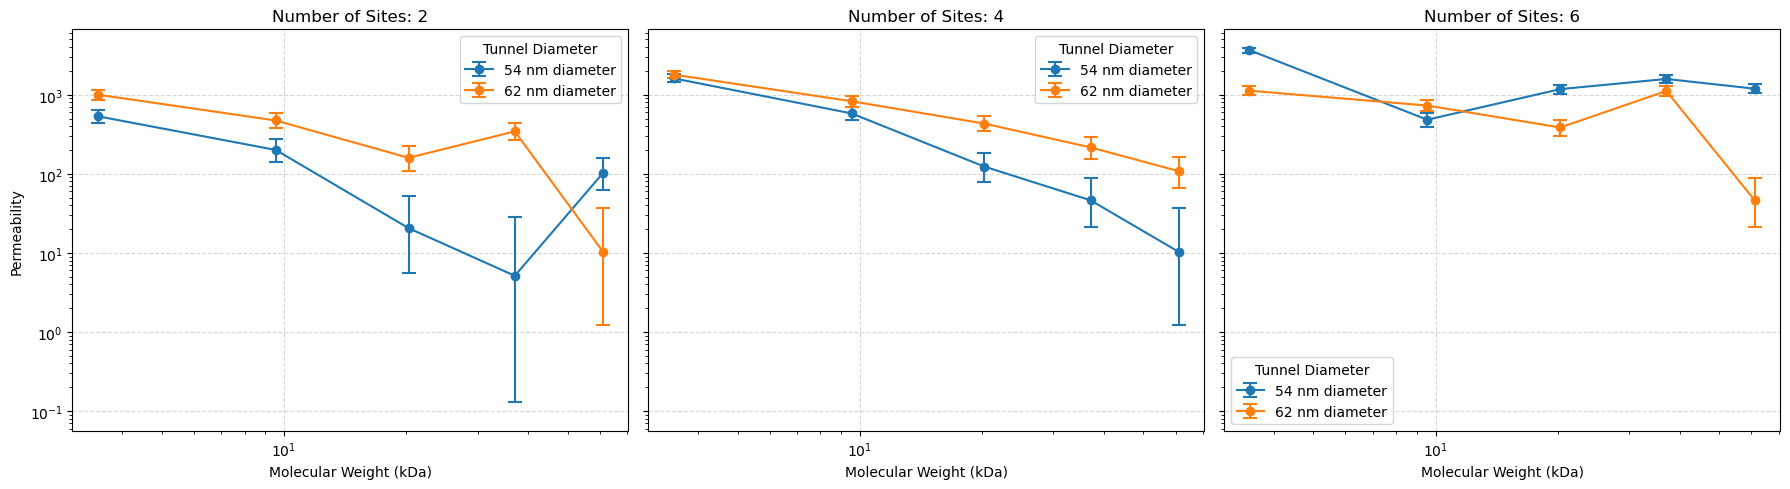

In [18]:

# Convert the results list of dicts to a Pandas DataFrame
df = pd.DataFrame(results)

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Get the unique site values (should be [2, 4, 6])
n_sites_list = sorted(df['sites'].unique())

for idx, sites in enumerate(n_sites_list):
    ax = axes[idx]
    
    # Filter data for the current number of sites
    df_sites = df[df['sites'] == sites]
    
    # Plot a line for each tunnel diameter
    for diameter in [54, 62]:
        df_plot = df_sites[df_sites['tunnel_diameter_nm'] == diameter].sort_values('kda')
        
        x = df_plot['kda']
        y = df_plot['permeability']
        
        # matplotlib expects the error distance from the point, not the absolute values
        yerr_lower = np.maximum(0, y - df_plot['lower_permeability'])
        yerr_upper = np.maximum(0, df_plot['upper_permeability'] - y)
        
        ax.errorbar(
            x, y, 
            yerr=[yerr_lower, yerr_upper], 
            label=f'{diameter} nm diameter', 
            marker='o', 
            capsize=5,       # Adds horizontal caps to the error bars
            capthick=1.5,
            elinewidth=1.5,
            linestyle='-'
        )
        
    ax.set_title(f'Number of Sites: {sites}')
    ax.set_xlabel('Molecular Weight (kDa)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    if idx == 0:
        ax.set_ylabel('Permeability')
        
    ax.legend(title='Tunnel Diameter')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()